# Ames Housing Price Predictor using OLS

**Dataset**: https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset  
**Background Info (source American Statistical Association):** https://jse.amstat.org/v19n3/decock.pdf  
**Metadata (source American Statistical Association):** https://jse.amstat.org/v19n3/decock/DataDocumentation.txt  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/AmesHousing.csv")

# Preview
pd.set_option('display.max_columns', None)
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
# Sanity Check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [3]:
# Create a copy of the original dataset
df_copy=df.copy()

In [4]:
# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "")

## **Exploratory Data Analysis**

In [5]:
df.describe()

,Order,PID,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemod/Add,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [6]:
# Calculate number of missing values
missing_count = df.isnull().sum()

# Calculate the missing percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

stats=pd.DataFrame({'column_name': df.columns,'missing_count': missing_count,'missing_percent': missing_percent}).reset_index(drop=True)
stats=stats.sort_values(by='missing_percent', ascending=False)
stats.head(10)

,column_name,missing_count,missing_percent
73,PoolQC,2917,99.556314
75,MiscFeature,2824,96.382253
7,Alley,2732,93.242321
74,Fence,2358,80.477816
26,MasVnrType,1775,60.580205
58,FireplaceQu,1422,48.532423
4,LotFrontage,490,16.723549
65,GarageCond,159,5.426621
61,GarageFinish,159,5.426621
60,GarageYrBlt,159,5.426621


In [7]:
# Drop columns with > 40% values missing
df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order          2930 non-null   int64  
 1   PID            2930 non-null   int64  
 2   MSSubClass     2930 non-null   int64  
 3   MSZoning       2930 non-null   object 
 4   LotFrontage    2440 non-null   float64
 5   LotArea        2930 non-null   int64  
 6   Street         2930 non-null   object 
 7   LotShape       2930 non-null   object 
 8   LandContour    2930 non-null   object 
 9   Utilities      2930 non-null   object 
 10  LotConfig      2930 non-null   object 
 11  LandSlope      2930 non-null   object 
 12  Neighborhood   2930 non-null   object 
 13  Condition1     2930 non-null   object 
 14  Condition2     2930 non-null   object 
 15  BldgType       2930 non-null   object 
 16  HouseStyle     2930 non-null   object 
 17  OverallQual    2930 non-null   int64  
 18  OverallC

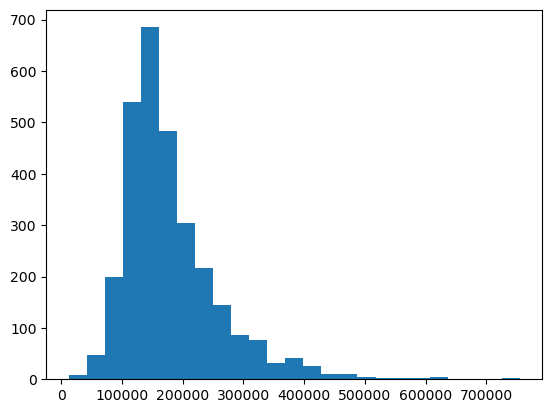

In [8]:
# Histogram of SalePrice is positively skewed
plt.hist(df['SalePrice'], bins=25)
plt.show()

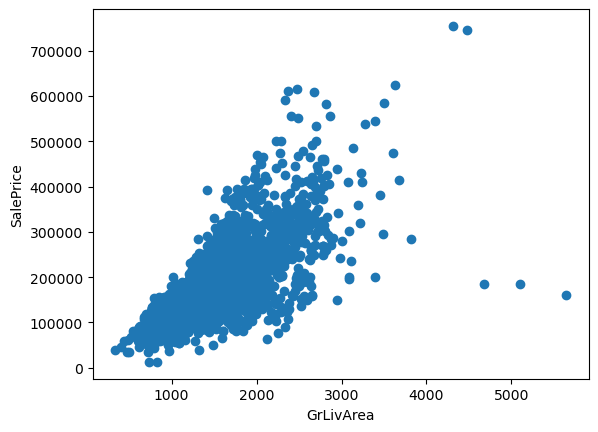

In [9]:
# Explore extreme outliers
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel("SalePrice")
plt.show()

In [10]:
# Rows # 1760 and 1767 - These two outliers are super-sized expensive dwellings
df[df['SalePrice'] > 700000]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1760,1761,528320050,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,NaN,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096.0,Unf,0.0,300.0,2396.0,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1.0,0.0,3,1,4,1,Ex,10,Typ,2,Attchd,1996.0,Fin,3.0,813.0,TA,TA,Y,171,78,0,0,0,555,0,7,2007,WD,Abnorml,745000
1767,1768,528351010,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455.0,Unf,0.0,989.0,2444.0,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0.0,1.0,3,1,4,1,Ex,10,Typ,2,Attchd,1994.0,Fin,3.0,832.0,TA,TA,Y,382,50,0,0,0,0,0,1,2007,WD,Normal,755000


In [11]:
# Rows # 1760 and 1767 - The two monster homes are also included here
# Rows # 1498, 2180, and 2181 - The other 3 entries are partial sales all in the Edwards Neighborhood
df[df['GrLivArea'] > 4000]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1498,1499,908154235,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644.0,Unf,0.0,466.0,6110.0,GasA,Ex,Y,SBrkr,4692,950,0,5642,2.0,0.0,2,1,3,1,Ex,12,Typ,3,Attchd,2008.0,Fin,2.0,1418.0,TA,TA,Y,214,292,0,0,0,480,0,1,2008,New,Partial,160000
1760,1761,528320050,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,NaN,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096.0,Unf,0.0,300.0,2396.0,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1.0,0.0,3,1,4,1,Ex,10,Typ,2,Attchd,1996.0,Fin,3.0,813.0,TA,TA,Y,171,78,0,0,0,555,0,7,2007,WD,Abnorml,745000
1767,1768,528351010,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455.0,Unf,0.0,989.0,2444.0,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0.0,1.0,3,1,4,1,Ex,10,Typ,2,Attchd,1994.0,Fin,3.0,832.0,TA,TA,Y,382,50,0,0,0,0,0,1,2007,WD,Normal,755000
2180,2181,908154195,20,RL,128.0,39290,Pave,IR1,Bnk,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,10,5,2008,2009,Hip,CompShg,CemntBd,CmentBd,Stone,1224.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,4010.0,Unf,0.0,1085.0,5095.0,GasA,Ex,Y,SBrkr,5095,0,0,5095,1.0,1.0,2,1,2,1,Ex,15,Typ,2,Attchd,2008.0,Fin,3.0,1154.0,TA,TA,Y,546,484,0,0,0,0,17000,10,2007,New,Partial,183850
2181,2182,908154205,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Stone,762.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2260.0,Unf,0.0,878.0,3138.0,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1.0,0.0,3,1,3,1,Ex,11,Typ,1,BuiltIn,2007.0,Fin,3.0,884.0,TA,TA,Y,208,406,0,0,0,0,0,10,2007,New,Partial,184750


In [12]:
# Check other partial sales in the Edwards Neighborhood
# Rows # 1498, 2180, and 2181 - These outliers have large square footage above grade but were sold at an incredibly low price
# That is, they likely don’t represent actual market values
temp=df[(df['Neighborhood'] == 'Edwards') & (df['SaleCondition'] == 'Partial')]
temp[['GrLivArea', 'SalePrice']]

,GrLivArea,SalePrice
241,1508,308030
1498,5642,160000
2177,1125,155000
2180,5095,183850
2181,4676,184750
2826,1072,140000
2827,1072,142500


In [13]:
# Rows # 1498, 1760, 1767, 2180, and 2181 - dropping these from dataset
df = df.drop([1498, 1760, 1767, 2180, 2181])
df.shape

(2925, 77)

In [14]:
# Drop data points that are unusual sales
df['SaleCondition'].value_counts()

SaleCondition
Normal     2412
Partial     242
Abnorml     189
Family       46
Alloca       24
AdjLand      12
Name: count, dtype: int64

## **Feature Engineering**

### **Total Functional Living Area - TotFuncLivArea**  
TotFuncLivArea describes the total functional living area in the dwelling, including all floors above grade and the basement.  Only average to high quality spaces were considered.  To get this data, we first imputed all missing values that are basement-related.  Subtracting LowQualFinSF from GrLivArea is equal to the space above grade that we are interested in. This was added to BsmtFinSF1 and BsmtFinSF2.  Only the following conditions were considered for BsmtFinType1 and BsmtFinType2: GLQ (Good Living Quarters), ALQ (Average Living Quarters), and Rec (Average Rec Room).

In [15]:
# Row 1341 - All basement fields are NaN, implicility implying no basement
df[df['TotalBsmtSF'].isna()]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1341,1342,903230120,20,RM,99.0,5940,Pave,IR1,Lvl,AllPub,FR3,Gtl,BrkSide,Feedr,Norm,1Fam,1Story,4,7,1946,1950,Gable,CompShg,MetalSd,CBlock,NaN,0.0,TA,TA,PConc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GasA,TA,Y,FuseA,896,0,0,896,NaN,NaN,1,0,2,1,TA,4,Typ,0,Detchd,1946.0,Unf,1.0,280.0,TA,TA,Y,0,0,0,0,0,0,0,4,2008,ConLD,Abnorml,79000


In [16]:
# Row 1341 - Fill in BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, and BsmtHalfBath with 0
cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
df.loc[1341, cols] = 0
df.loc[[1341]]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1341,1342,903230120,20,RM,99.0,5940,Pave,IR1,Lvl,AllPub,FR3,Gtl,BrkSide,Feedr,Norm,1Fam,1Story,4,7,1946,1950,Gable,CompShg,MetalSd,CBlock,NaN,0.0,TA,TA,PConc,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,GasA,TA,Y,FuseA,896,0,0,896,0.0,0.0,1,0,2,1,TA,4,Typ,0,Detchd,1946.0,Unf,1.0,280.0,TA,TA,Y,0,0,0,0,0,0,0,4,2008,ConLD,Abnorml,79000


In [17]:
# Fill in all non-numerical basement columns with None if Total Bsmt SF=0
cols_to_fix = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df.loc[df['TotalBsmtSF'] == 0, cols_to_fix] = 'None'
df[df['TotalBsmtSF']==0]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
83,84,532351140,90,RM,68.0,8930,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,RRAe,Norm,Duplex,1.5Fin,6,5,1978,1978,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,TA,Y,SBrkr,1318,584,0,1902,0.0,0.0,2,0,4,2,TA,8,Typ,0,Attchd,1978.0,Unf,2.0,539.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Normal,112000
154,155,535327140,20,RL,60.0,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,7,1955,2007,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,Ex,Y,SBrkr,827,0,0,827,0.0,0.0,1,0,2,1,TA,5,Mod,1,Detchd,1967.0,Unf,1.0,392.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Normal,107500
206,207,903454060,190,RM,70.0,5600,Pave,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,2fmCon,2Story,4,5,1930,1950,Hip,CompShg,VinylSd,Wd Shng,NaN,0.0,Fa,Fa,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,Fa,N,SBrkr,372,720,0,1092,0.0,0.0,2,0,3,2,Fa,7,Mod,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,N,0,0,0,0,0,0,3500,7,2010,WD,Normal,55000
243,244,905478190,20,RL,60.0,11100,Pave,Reg,Low,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,4,7,1946,2006,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,Ex,Y,SBrkr,930,0,0,930,0.0,0.0,1,0,2,1,Gd,6,Typ,0,Detchd,1946.0,Unf,1.0,308.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Abnorml,84900
273,274,908102060,30,RL,67.0,8777,Pave,Reg,Lvl,AllPub,Inside,Mod,Edwards,Feedr,Norm,1Fam,1Story,3,6,1945,2007,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,Gd,CBlock,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,TA,N,SBrkr,640,0,0,640,0.0,0.0,1,0,2,1,TA,5,Min1,0,Detchd,1945.0,Unf,1.0,240.0,TA,TA,N,0,0,0,0,0,0,0,4,2010,ConLD,Normal,84900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2739,2740,905451050,20,RL,80.0,12048,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1952,2002,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,232.0,TA,TA,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,Gd,Y,SBrkr,1488,0,0,1488,0.0,0.0,1,0,3,1,TA,7,Typ,1,Attchd,2002.0,RFn,2.0,569.0,TA,TA,Y,0,189,36,0,348,0,0,4,2006,WD,Normal,135000
2744,2745,905477010,20,RL,77.0,8335,Pave,Reg,Lvl,AllPub,Corner,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,5,1954,1954,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,Gd,Y,SBrkr,1124,0,0,1124,0.0,0.0,1,0,3,1,TA,5,Min2,1,NaN,NaN,NaN,0.0,0.0,NaN,NaN,N,0,36,190,0,0,0,0,4,2006,WD,Normal,93000
2879,2880,911175410,30,C (all),69.0,12366,Pave,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Feedr,Norm,1Fam,1Story,3,5,1945,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,TA,N,SBrkr,729,0,0,729,0.0,0.0,1,0,2,1,TA,5,Mod,0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,N,0,0,23,0,0,0,0,10,2006,WD,Abnorml,51689
2892,2893,916252170,120,RM,NaN,8239,Pave,IR1,Lvl,AllPub,Inside,Gtl,GrnHill,Norm,Norm,TwnhsE,1Story,7,5,1986,1986,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,Gd,TA,CBlock,None,None,None,None,0.0,None,0.0,0.0,0.0,GasA,Gd,

In [18]:
# Row #444 - There is a contradiction.  BsmtFinType2=NA, but BsmtFinSF2!=0.  Treat as a missing value
df[df['BsmtFinType2'].isna()]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
444,445,528142130,20,RL,85.0,10655,Pave,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2003,2004,Gable,CompShg,VinylSd,VinylSd,BrkFace,296.0,Gd,TA,PConc,Gd,TA,No,GLQ,1124.0,NaN,479.0,1603.0,3206.0,GasA,Ex,Y,SBrkr,1629,0,0,1629,1.0,0.0,2,0,3,1,Gd,7,Typ,1,Attchd,2003.0,RFn,3.0,880.0,TA,TA,Y,0,0,0,0,0,0,0,10,2009,WD,Normal,284000


In [19]:
# Unf (i.e. Unfinished) is the most commonly occurring category in BsmtFinSF2, so we'll use it impute the missing data
df['BsmtFinType2'].mode()

0    Unf
Name: BsmtFinType2, dtype: object

In [20]:
# Row #444 - Impute missing value for BsmtFinType2
temp=df
df.fillna({'BsmtFinType2': df['BsmtFinType2'].mode()[0]}, inplace=True)
df.loc[[444]]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
444,445,528142130,20,RL,85.0,10655,Pave,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2003,2004,Gable,CompShg,VinylSd,VinylSd,BrkFace,296.0,Gd,TA,PConc,Gd,TA,No,GLQ,1124.0,Unf,479.0,1603.0,3206.0,GasA,Ex,Y,SBrkr,1629,0,0,1629,1.0,0.0,2,0,3,1,Gd,7,Typ,1,Attchd,2003.0,RFn,3.0,880.0,TA,TA,Y,0,0,0,0,0,0,0,10,2009,WD,Normal,284000


In [21]:
from scipy import stats
from scipy.stats import chi2_contingency

# Chi-Square Test - Confirms imputation did not distort category distributions

def chiSquareFunc(original_counts, imputed_counts):

    # Align indexes to handle missing categories
    table = pd.DataFrame({'original': original_counts, 'imputed': imputed_counts})

    chi2, p, dof, expected = chi2_contingency(table.T)
    print(f"Chi-square = {chi2:.3f}, p-value = {p:.3f}")

In [22]:
# p-value >= 0.05 means Imputation did not distort category distribution
# That is, the distributions are statistically similar.
chiSquareFunc(temp['BsmtFinType2'].value_counts(), df['BsmtFinType2'].value_counts())

Chi-square = 0.000, p-value = 1.000


In [23]:
# Rows 66,96,79 - Bsmt Expsure is NAN (i.e No basement), but Total BSMT SF !=0.  This is a contradition.
# Treat as missing values
df[df['BsmtExposure'].isna()]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
66,67,528445060,20,RL,73.0,8987,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2005,2006,Gable,CompShg,VinylSd,VinylSd,BrkFace,226.0,Gd,TA,PConc,Gd,TA,NaN,Unf,0.0,Unf,0.0,1595.0,1595.0,GasA,Ex,Y,SBrkr,1595,0,0,1595,0.0,0.0,2,0,2,1,Gd,6,Typ,1,Attchd,2005.0,RFn,3.0,880.0,TA,TA,Y,144,0,0,0,0,0,0,5,2010,WD,Normal,221500
1796,1797,528458090,60,FV,81.0,10411,Pave,Reg,Lvl,AllPub,Corner,Gtl,Somerst,Norm,Norm,1Fam,2Story,5,5,2007,2007,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,CBlock,Gd,TA,NaN,Unf,0.0,Unf,0.0,725.0,725.0,GasA,Ex,Y,SBrkr,725,863,0,1588,0.0,0.0,3,0,3,1,Gd,8,Typ,0,Attchd,2007.0,Unf,2.0,561.0,TA,TA,Y,0,0,0,0,0,0,0,7,2007,New,Partial,212109
2779,2780,907194130,60,RL,65.0,14006,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,144.0,Gd,TA,PConc,Gd,TA,NaN,Unf,0.0,Unf,0.0,936.0,936.0,GasA,Ex,Y,SBrkr,936,840,0,1776,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Attchd,2002.0,RFn,2.0,474.0,TA,TA,Y,144,96,0,0,0,0,0,2,2006,WD,Normal,192500


In [24]:
# No (i.e. No Exposure) is the most commonly occurring category in BsmtFinSF2, so we'll use it impute the missing data
df['BsmtExposure'].mode()

0    No
Name: BsmtExposure, dtype: object

In [25]:
# Rows #66, 96, and 79 - Impute missing value for BsmtFinType2
temp=df
df.fillna({'BsmtExposure': df['BsmtExposure'].mode()[0]}, inplace=True)
df.loc[[66, 96, 79]]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
66,67,528445060,20,RL,73.0,8987,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2005,2006,Gable,CompShg,VinylSd,VinylSd,BrkFace,226.0,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,1595.0,1595.0,GasA,Ex,Y,SBrkr,1595,0,0,1595,0.0,0.0,2,0,2,1,Gd,6,Typ,1,Attchd,2005.0,RFn,3.0,880.0,TA,TA,Y,144,0,0,0,0,0,0,5,2010,WD,Normal,221500
96,97,533212010,160,FV,30.0,3182,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,TwnhsE,2Story,7,5,2004,2005,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,600.0,600.0,GasA,Ex,Y,SBrkr,600,600,0,1200,0.0,0.0,2,1,2,1,Gd,4,Typ,0,Detchd,2004.0,RFn,2.0,480.0,TA,TA,Y,0,172,0,0,0,0,0,6,2010,WD,Normal,151000
79,80,531452180,60,RL,NaN,9453,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,SawyerW,RRNe,Norm,1Fam,2Story,7,7,1993,2003,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,BLQ,402.0,Unf,0.0,594.0,996.0,GasA,Ex,Y,SBrkr,1014,730,0,1744,0.0,0.0,2,1,3,1,Gd,7,Typ,0,Attchd,1993.0,RFn,2.0,457.0,TA,TA,Y,370,70,0,238,0,0,0,2,2010,WD,Normal,194500


In [26]:
# p-value >= 0.05 means Imputation did not distort category distribution
# That is, the distributions are statistically similar.
chiSquareFunc(temp['BsmtExposure'].value_counts(), df['BsmtExposure'].value_counts())

Chi-square = 0.000, p-value = 1.000


In [27]:
# Create new variable TotFuncLivArea

# Only consider average to good basement spaces
bsmt_types = ['GLQ', 'ALQ', 'Rec']

df['TotFuncLivArea'] = (
    df['BsmtFinSF1'].where(df['BsmtFinType1'].isin(bsmt_types), 0) +
    df['BsmtFinSF2'].where(df['BsmtFinType2'].isin(bsmt_types), 0) +
    (df['GrLivArea'] - df['LowQualFinSF'])
)

Text(0, 0.5, 'SalePrice')

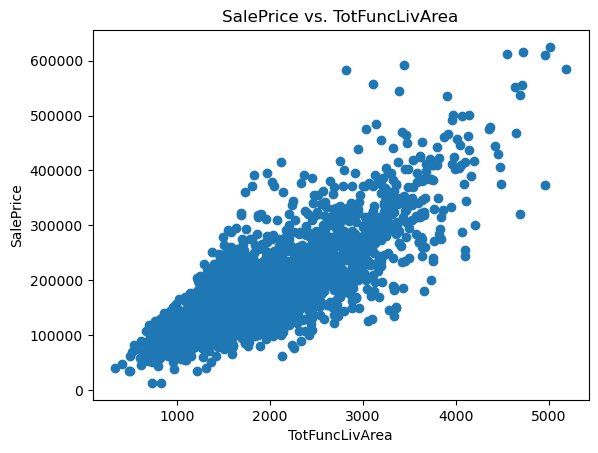

In [28]:
plt.scatter(df['TotFuncLivArea'], df['SalePrice'] )
plt.title('SalePrice vs. TotFuncLivArea')
plt.xlabel('TotFuncLivArea')
plt.ylabel('SalePrice')

### **Neighborhood Encoded Train and Test - NeighborhoodEncTrain, NeighborhoodEncTest**  
Since the Neighborhood column is nominal and has high cardinality (i.e. 28 neighborhoods), we decided to take a stab at target encoding.  We can't simply use the mean SalePrice for each neighborhood since this could potentially lead to data leakage and overfitting. Therefore we use target encoding.  

Smoothing calculates a weighted average between the category mean and the global mean.  For neighborhoods with lower counts, the encoding leans toward the global mean.  For neighborhoods with higher counts, the encoding leans toward the category mean.  

k-fold cross-fitting eliminates data leakage (i.e. you can't include a house's price to determine the average neighborhood price for the same house).  

The NeighborhoodEncTrain will be used for training the OLS model, and NeighborhoodEncTest will be used for testing.

In [29]:
group=df.groupby('Neighborhood')['SalePrice'].agg(['count', 'mean']).sort_values(by='mean', ascending=True).reset_index()
group

,Neighborhood,count,mean
0,MeadowV,37,95756.486486
1,IDOTRR,93,103752.903226
2,BrDale,30,105608.333333
3,OldTown,239,123991.891213
4,BrkSide,108,124756.250000
5,Edwards,191,130130.973822
6,SWISU,48,135071.937500
7,Sawyer,151,136751.152318
8,Landmrk,1,137000.000000
9,NPkVill,23,140710.869565


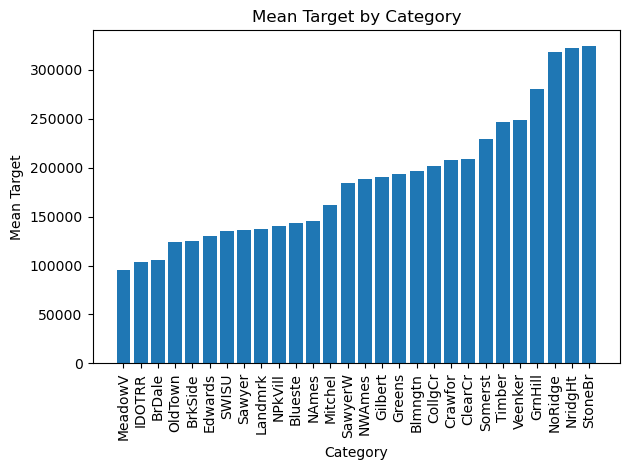

In [30]:
plt.bar(group['Neighborhood'], group['mean'])

plt.xlabel('Category')
plt.ylabel('Mean Target')
plt.title('Mean Target by Category')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [31]:
# We can't simply use the mean SalePrice for each neighborhood due to data leakage and overfitting. Therefore we use target encoding.
# We use auto smoothing and default value of k-folds=5

from sklearn.preprocessing import TargetEncoder

# Define variables for target encoding
X=df[['Neighborhood']]
y=df['SalePrice']

# Perform encoding on training data.  Smoothing helps prevent overfitting
te = TargetEncoder(smooth="auto",target_type='continuous')
df['NeighborhoodEncTrain'] = te.fit_transform(X, y)

# Perform encoding on testing data
df['NeighborhoodEncTest'] = te.transform(X)

df

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotFuncLivArea,NeighborhoodEncTrain,NeighborhoodEncTest
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,0,5,2010,WD,Normal,215000,1656.0,144960.925835,145110.451240
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,0,6,2010,WD,Normal,105000,1364.0,144687.327631,145110.451240
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,12500,6,2010,WD,Normal,172000,2252.0,145099.156330,145110.451240
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Normal,244000,3175.0,146158.174528,145110.451240
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,0,3,2010,WD,Normal,189900,2420.0,189826.983472,190635.670222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,1Fam,SLvl,6,6,1984,1984,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,Av,GLQ,819.0,Unf,0.0,184.0,1003.0,GasA,TA,Y,SBrkr,1003,0,0,1003,1.0,0.0,1,0,3,1,TA,6,Typ,0,Detchd,1984.0,Unf,2.0,588.0,TA,TA,Y,120,0,0,0,0,0,0,3,2006,WD,Normal,142500,1822.0,161978.015743,162270.366918
2926,2927,923276100,20,RL,NaN,8885,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1983,1983,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,Gd,TA,Av,BLQ,301.0,ALQ,324.0,239.0,864.0,GasA,TA,Y,SBrkr,902,0,0,902,1.0,0.0,1,0,2,1,TA,5,Typ,0,Attchd,1983.0,Unf,2.0,484.0,TA,TA,Y,164,0,0,0,0,0,0,6,2006,WD,Normal,131000,1226.0,164420.704649,162270.366918
2927,2928,923400125,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0

Text(0, 0.5, 'SalePrice')

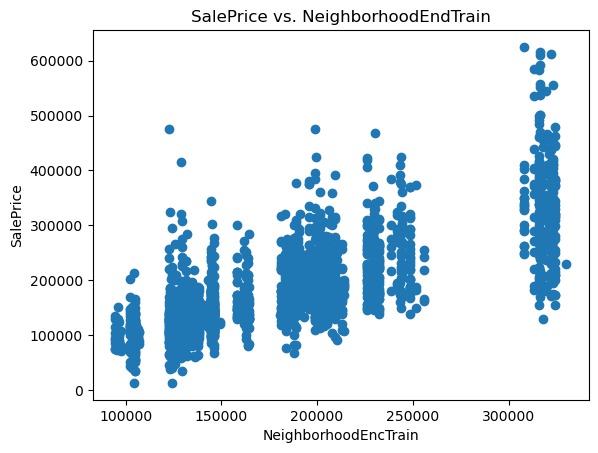

In [32]:
plt.scatter(df['NeighborhoodEncTrain'], df['SalePrice'] )
plt.title('SalePrice vs. NeighborhoodEndTrain')
plt.xlabel('NeighborhoodEncTrain')
plt.ylabel('SalePrice')

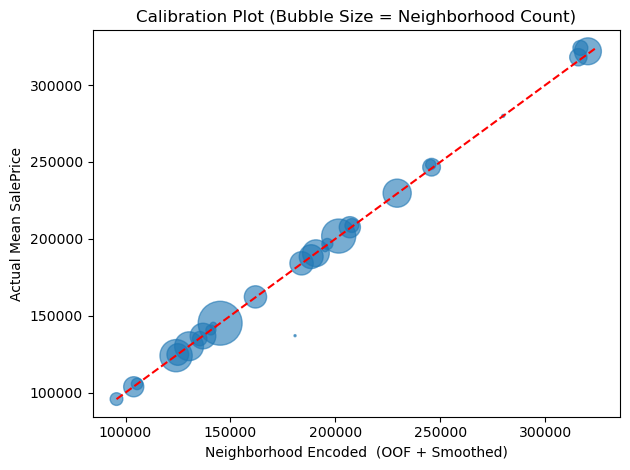

In [33]:
# Calibration plot indicates that majority of bubbles fall on the y=x line, implying that target encoding is near perfect.
# However, there is one excpetion, there is a tiny bubble at around (180,000, 140,000), representing the neighborhood of Landmark.
# In the dataset, there is only 1 sale in Landmark, so there will be a overfitting for that particualr neighborhood.

# Group by neighbouhood
group = df.groupby('Neighborhood').agg(
    encoded=('NeighborhoodEncTrain', 'mean'),
    actual=('SalePrice', 'mean'),
    count=('SalePrice', 'size')
).reset_index()

# Sort for readability
group = group.sort_values('encoded')

plt.figure()

x = range(len(group))

# Normalize bubble sizes
sizes = group['count'] / group['count'].max() * 1000

# Scatterplot
plt.scatter(group['encoded'], group['actual'], s=sizes, alpha=0.6)
plt.title('Calibration Plot (Bubble Size = Neighborhood Count)')
plt.xlabel('Neighborhood Encoded  (OOF + Smoothed)')
plt.ylabel('Actual Mean SalePrice')

# Plot 45-degree line
min_val = min(group['encoded'].min(), group['actual'].min())
max_val = max(group['encoded'].max(), group['actual'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.tight_layout()
plt.show()

### **Evaluation of Basement Height in Numerical Form - BsmtQualNum**  
The original BsmtQual field was ordinal encoded so that it can be compatible with OLS modelling.  The following mapping scheme was applied to the data:

4 = Ex	Excellent (100+ inches)  
3 = Gd	Good (90-99 inches)  
2 = TA	Typical (80-89 inches)  
1 = Fa	Fair (70-79 inches)  
0 = Po	Poor (<70 inches)  
0 = None	No Basement

In [34]:
# Only 2 properties have poor rating.  Bin none and poor together so that distribution of values is more balanced.
df['BsmtQual'].value_counts()

BsmtQual
TA      1283
Gd      1219
Ex       253
Fa        88
None      80
Po         2
Name: count, dtype: int64

In [35]:
# Combine None and Po categories together via mapping
mapping = {
    'Ex': 4,
    'Gd': 3,
    'TA': 2,
    'Fa': 1,
    'Po': 0,
    'None': 0
}
df['BsmtQualNum'] = df['BsmtQual'].map(mapping)

Text(0, 0.5, 'SalePrice')

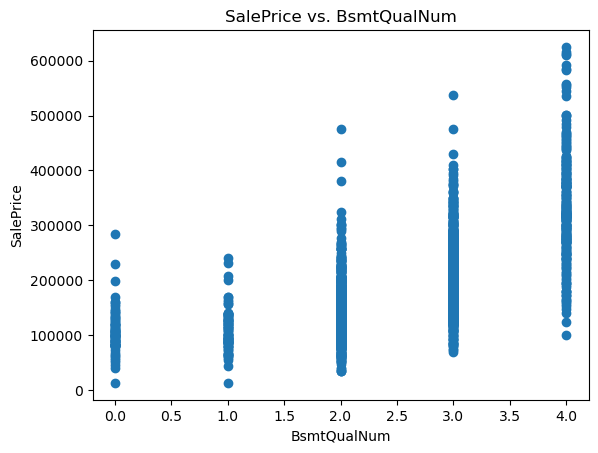

In [36]:
plt.scatter(df['BsmtQualNum'], df['SalePrice'] )
plt.title('SalePrice vs. BsmtQualNum')
plt.xlabel('BsmtQualNum')
plt.ylabel('SalePrice')

### **Evaluation of Material Quality on the Exterior in Numerical Form - ExterQualNum**  
The original ExterQual field was ordinal encoded so that it can be compatible with OLS modelling.  The following mapping scheme was applied to the data:

4 = Ex	Excellent  
3 = Gd	Good  
2 = TA	Average/Typical  
1 = Fa	Fair  
0 = Po	Poor

In [37]:
df['ExterQual'].value_counts()

ExterQual
TA    1799
Gd     988
Ex     103
Fa      35
Name: count, dtype: int64

In [38]:
# Mapping scheme
mapping = {
    'Ex': 4,
    'Gd': 3,
    'TA': 2,
    'Fa': 1,
    'Po': 0
}
df['ExterQualNum'] = df['ExterQual'].map(mapping)

Text(0, 0.5, 'SalePrice')

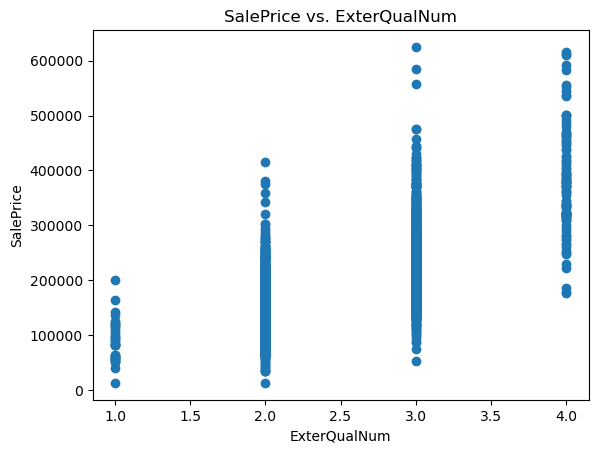

In [39]:
plt.scatter(df['ExterQualNum'], df['SalePrice'] )
plt.title('SalePrice vs. ExterQualNum')
plt.xlabel('ExterQualNum')
plt.ylabel('SalePrice')

### **Evaluation of Kitchen Quality in Numerical Form - KitchenQualNum**  
The original KitchenQual field was ordinal encoded so that it can be compatible with OLS modelling.  The following mapping scheme was applied to the data:

3 = Ex	Excellent  
2 = Gd	Good  
1 = TA	Average/Typical  
0 = Fa	Fair  
0 = Po	Poor

In [40]:
# Only 1 property has poor rating.  Bin poor and fair together so that distribution of values is more balanced.
df['KitchenQual'].value_counts()

KitchenQual
TA    1494
Gd    1160
Ex     200
Fa      70
Po       1
Name: count, dtype: int64

In [41]:
# Combine Po and Fair categories together via mapping
mapping = {
    'Ex': 3,
    'Gd': 2,
    'TA': 1,
    'Fa': 0,
    'Po': 0
}
df['KitchenQualNum'] = df['KitchenQual'].map(mapping)

Text(0, 0.5, 'SalePrice')

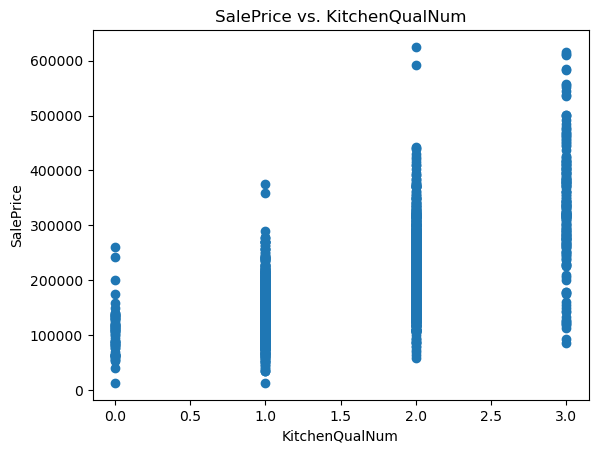

In [42]:
plt.scatter(df['KitchenQualNum'], df['SalePrice'] )
plt.title('SalePrice vs. KitchenQualNum')
plt.xlabel('KitchenQualNum')
plt.ylabel('SalePrice')

### **Log of SalePrice - LogSalePrice**  
When SalePrice is plotted against other variables, this typically results in a data distribution that fans out along the line of best fit (i.e. this implies that there is heteroscedasticity in the residuals).  For this reason, we have decided to also analyze the SalePrice with the log function applied to it.

In [43]:
df['LogSalePrice'] = np.log(df['SalePrice'])
df['LogSalePrice']

0       12.278393
1       11.561716
2       12.055250
3       12.404924
4       12.154253
          ...    
2925    11.867097
2926    11.782953
2927    11.790557
2928    12.043554
2929    12.144197
Name: LogSalePrice, Length: 2925, dtype: float64

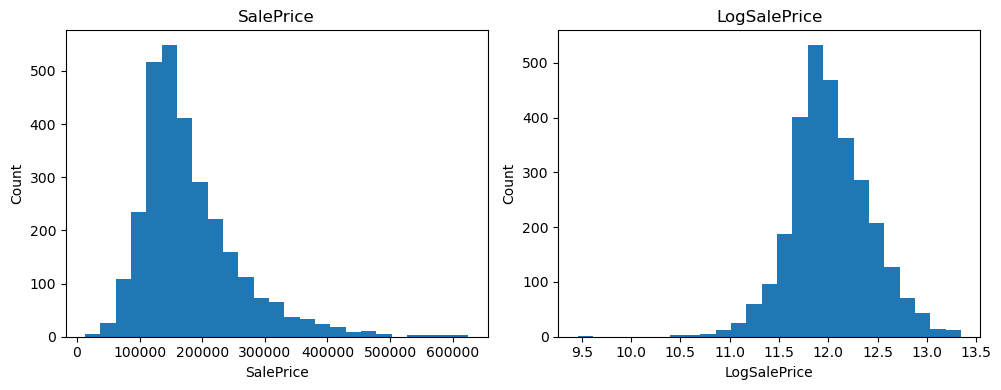

In [44]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df['SalePrice'], bins=25)
ax1.set_title('SalePrice')
ax1.set_xlabel('SalePrice')
ax1.set_ylabel('Count')

ax2.hist(df['LogSalePrice'], bins=25)
ax2.set_title("LogSalePrice")
ax2.set_xlabel('LogSalePrice')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [45]:
from scipy.stats import skew

print("Skewness SalePrice:", skew(df['SalePrice']))
print("Skewness LogSalePrice:", skew(df['LogSalePrice']))

Skewness SalePrice: 1.590256360223393
Skewness LogSalePrice: -0.04192653935727468


As shown in the plot, the SalePrice is right-skewed (skewness score of 1.59) while Log transformation makes it more symmetric and closer to a normal distribution (skewness score close to 0). In other words, the log transformation reduces skewness and stabilizes variance, making the target variable more normally distributed and better suited for linear modeling.

In [46]:
# Create a copy of the global dataset
df_global=df.copy()
df_anita=df.copy() # Anita
df_dmitry=df.copy() # Dmitry
df_tx = df.copy() # Dimpal
df_time = df.copy() # Michael
df_forestmodel = df.copy() #Marisol

df['YrSold'].value_counts().sort_index()

YrSold
2006    625
2007    690
2008    621
2009    648
2010    341
Name: count, dtype: int64

## **OLS Modelling and Predictive Analysis**

**Credit goes to teammate Loris Fossier for his work on determining the most influential variables.**
  
I carried out a feature screening / exploratory analysis to determine the top 10 variables most strongly associated with SalePrice. To do that, I separate the numerical variables and categorical variables. I then combined both results in a single heatmap.  Below is the computational methods used:  
  
* Computed Pearson correlation for numeric variables  
* Computed ANOVA + Eta² for categorical variables  
* Combined both into a single ranking + heatmap


This analysis measures association but does NOT yet measure true predictive influence. It essentially gives a candidate shortlist of most strongly associated variables with SalePrice.

Top numerical variables correlated with LogSalePrice:
OverallQual             0.827560
TotFuncLivArea          0.770635
NeighborhoodEncTest     0.748244
NeighborhoodEncTrain    0.743485
GrLivArea               0.711342
ExterQualNum            0.686567
GarageCars              0.675345
BsmtQualNum             0.673143
KitchenQualNum          0.667413
GarageArea              0.654072
TotalBsmtSF             0.649055
1stFlrSF                0.620980
YearBuilt               0.616823
YearRemod/Add           0.587848
GarageYrBlt             0.582135
Name: LogSalePrice, dtype: float64


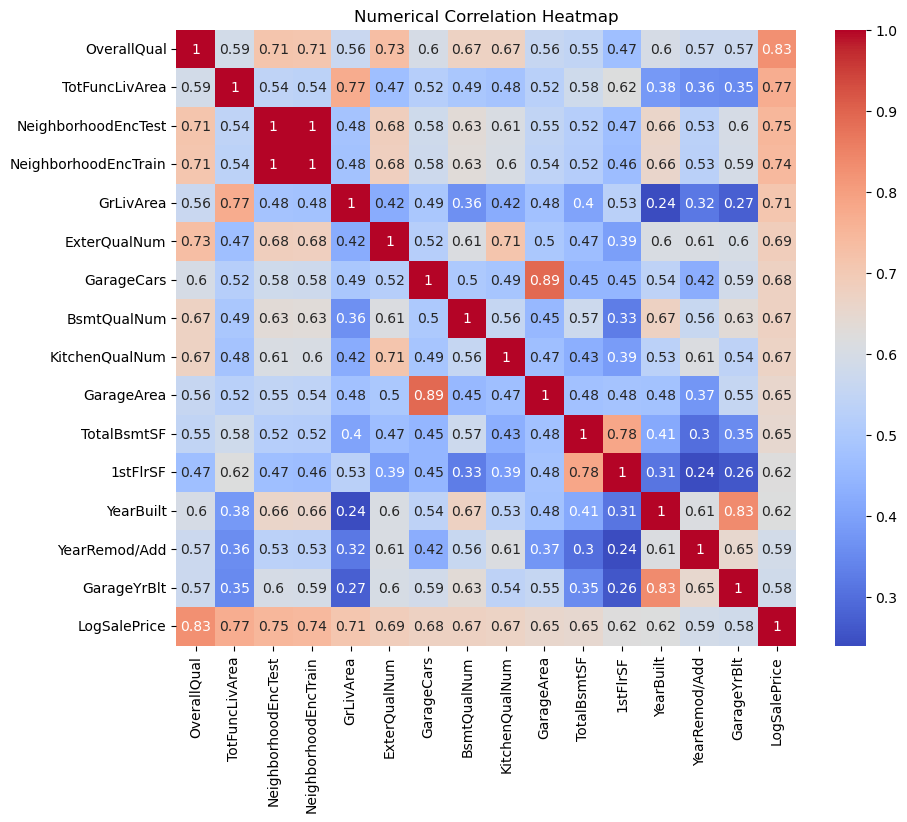

In [47]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# 2. Correlation Analysis on Numerical Data
# Note: SalePrice was removed from the feature set to avoid leakage

numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["SalePrice"])

# Compute correlation with target
num_corr = numeric_df.corr()["LogSalePrice"].sort_values(ascending=False)

# Remove self-correlation
num_corr = num_corr.drop("LogSalePrice", errors="ignore")

# Top correlated variables
top_num_corr = num_corr.head(15)

print("Top numerical variables correlated with LogSalePrice:")
print(top_num_corr)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df[top_num_corr.index.tolist() + ["LogSalePrice"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Numerical Correlation Heatmap")
plt.show()

# Convert to DataFrame for later combination
num_corr_df = num_corr.to_frame(name="Score")



Top categorical variables influencing LogSalePrice:
          Feature        p-value  EtaSquared
6    Neighborhood   0.000000e+00    0.580926
19       BsmtQual   0.000000e+00    0.485893
16      ExterQual   0.000000e+00    0.471699
28    KitchenQual   0.000000e+00    0.446814
18     Foundation  1.530237e-243    0.321305
31   GarageFinish  6.281224e-230    0.317517
30     GarageType  8.827312e-185    0.268825
25      HeatingQC  8.083213e-180    0.244172
22   BsmtFinType1  6.093836e-173    0.243740
13    Exterior1st  4.002282e-132    0.196345
14    Exterior2nd  3.596423e-119    0.182252
0        MSZoning  6.874864e-125    0.178092
21   BsmtExposure  1.160940e-117    0.171556
36  SaleCondition   2.771432e-93    0.140414
34     PavedDrive   3.943266e-95    0.138245


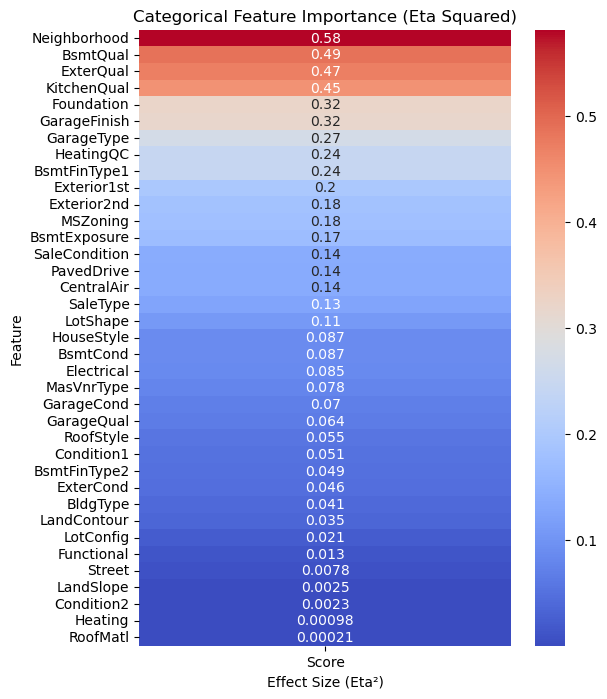

In [48]:
# 3. Categorical vs LogSalePrice (ANOVA + Effect Size)

categorical_cols = df.select_dtypes(exclude=[np.number]).columns

results = []

for col in categorical_cols:

    temp_df = df[[col, "LogSalePrice"]].dropna(subset=[col])

    if temp_df[col].nunique() > 50:
        continue

    min_group_size = 10
    groups = [
        group["LogSalePrice"].values
        for name, group in temp_df.groupby(col)
        if len(group) >= min_group_size
    ]

    if len(groups) < 2:
        continue

    f_val, p_val = stats.f_oneway(*groups)

    overall_mean = temp_df["LogSalePrice"].mean()

    ss_between = sum(
        len(group) * (group.mean() - overall_mean) ** 2
        for name, group in temp_df.groupby(col)["LogSalePrice"]
        if len(group) >= min_group_size
    )

    ss_total = sum((temp_df["LogSalePrice"] - overall_mean) ** 2)

    eta_sq = ss_between / ss_total if ss_total != 0 else 0

    results.append((col, p_val, eta_sq))

anova_df = pd.DataFrame(results, columns=["Feature", "p-value", "EtaSquared"])
anova_df = anova_df.sort_values(by="EtaSquared", ascending=False)

print("Top categorical variables influencing LogSalePrice:")
print(anova_df.head(15))

# Heatmap
cat_corr_df = anova_df.set_index("Feature")[["EtaSquared"]]
cat_corr_df.columns = ["Score"]

plt.figure(figsize=(6, 8))
sns.heatmap(cat_corr_df, annot=True, cmap="coolwarm", cbar=True)

plt.title("Categorical Feature Importance (Eta Squared)")
plt.ylabel("Feature")
plt.xlabel("Effect Size (Eta²)")
plt.show()


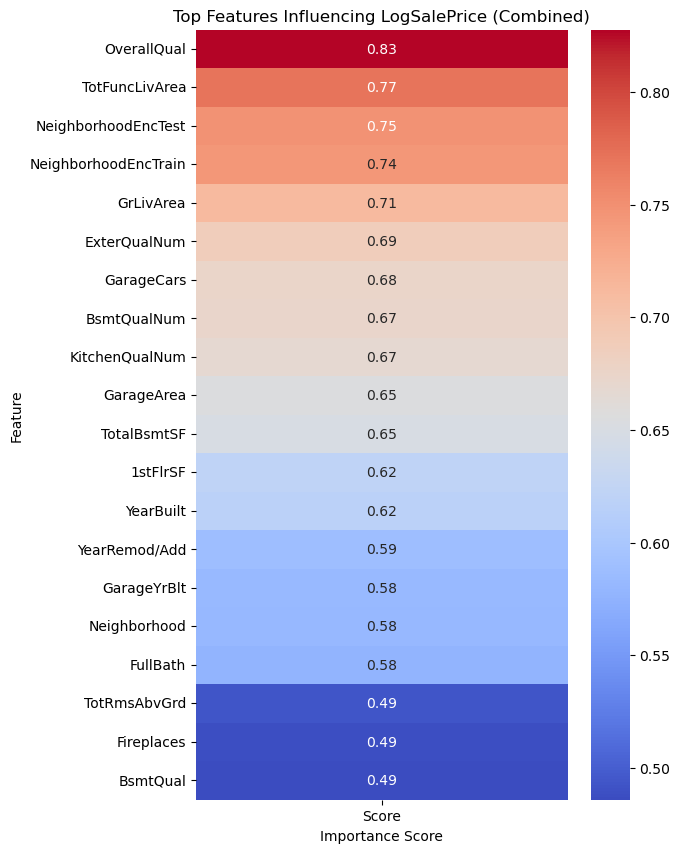

In [49]:
# 4. Combined Heatmap (Numeric + Categorical)

# Remove SalePrice if still present
num_corr_df = num_corr_df.drop("SalePrice", errors="ignore")

# Combine both
combined = pd.concat([num_corr_df, cat_corr_df])

# Ensure comparable scale (absolute values)
combined["Score"] = combined["Score"].abs()

# Select top features
combined = combined.sort_values(by="Score", ascending=False).head(20)

# Plot
plt.figure(figsize=(6, 10))
sns.heatmap(combined, annot=True, cmap="coolwarm")

plt.title("Top Features Influencing LogSalePrice (Combined)")
plt.ylabel("Feature")
plt.xlabel("Importance Score")
plt.show()

The combined feature importance analysis integrates numerical correlations with LogSalePrice and categorical feature importance measured using ANOVA effect size (Eta²). While numerical features appear more prominent in the ranking, it is important to note that these metrics are not directly comparable. Instead, the results highlight the strongest predictors across both feature types.

Several categorical variables (such as Neighbourhood, BsmtQual, ExterQual, and KitchenQual) show strong influence once encoded numerically. This confirms that encoding allows these categorical features to effectively capture pricing signals and be incorporated into the modeling process.

Based on the combined ranking, the following features are retained:

* OverallQual
* TotFuncLivArea (replacing 1stFlrSF and TotalBsmtSF to avoid redundancy)
* NeighborhoodEncTrain (encoded version retained; raw Neighbourhood removed)
* GrLivArea
* ExterQualNum
* GarageCars
* BsmtQualNum
* KitchenQualNum
* GarageArea
* YearBuilt
* YearRemod/Add
* GarageYrBlt
* FullBath

**My OLS Model**
I will be using the top 3 influential features to predict SalePrice. The goal is to create a model with reasonably good predictive performance, while keeping data dimensionality as low as possible.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define predictors and target
X = df[['Neighborhood', 'OverallQual', 'TotFuncLivArea']]
y = df['LogSalePrice']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Get the same train and test sets everytime

# Target Encoding
te = TargetEncoder(smooth='auto', target_type='continuous')
X_train['Neighborhood_te'] = te.fit_transform(X_train[['Neighborhood']], y_train) # Transform training data
X_test['Neighborhood_te'] = te.transform(X_test[['Neighborhood']]) # Transform test data
X_train = X_train.drop(columns=['Neighborhood']) # Drop original Neighborhood columns from training data
X_test = X_test.drop(columns=['Neighborhood']) # Drop original Neighborhood columns from test data

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index) # Convert back to DataFrame
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index) # Convert back to DataFrame

# Check VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
print(vif_data)
print('\n')

# Add constant
X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled = sm.add_constant(X_test_scaled)

# Fit OLS model
model = sm.OLS(y_train, X_train_scaled).fit()
print(model.summary())

           feature       VIF
0      OverallQual  2.275496
1   TotFuncLivArea  1.566853
2  Neighborhood_te  2.052716


                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     3795.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        20:58:37   Log-Likelihood:                 875.32
No. Observations:                2340   AIC:                            -1743.
Df Residuals:                    2336   BIC:                            -1720.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------

In [51]:
model_q1 = model
X_q1 = X_train_scaled
y_q1 = y_train

In [52]:
print(f'Shape of Training Set: X_train={X_train_scaled.shape}, y_train={y_train.shape}')
print(f'Shape of Test Set: X_test={X_test_scaled.shape}, y_test={y_test.shape}')

Shape of Training Set: X_train=(2340, 4), y_train=(2340,)
Shape of Test Set: X_test=(585, 4), y_test=(585,)


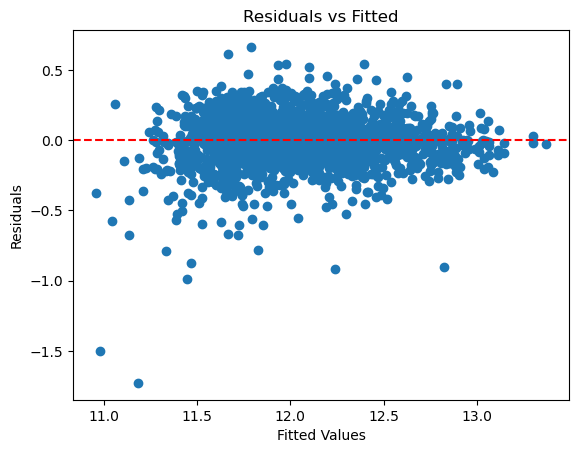

In [53]:
plt.scatter(model.fittedvalues , model.resid)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

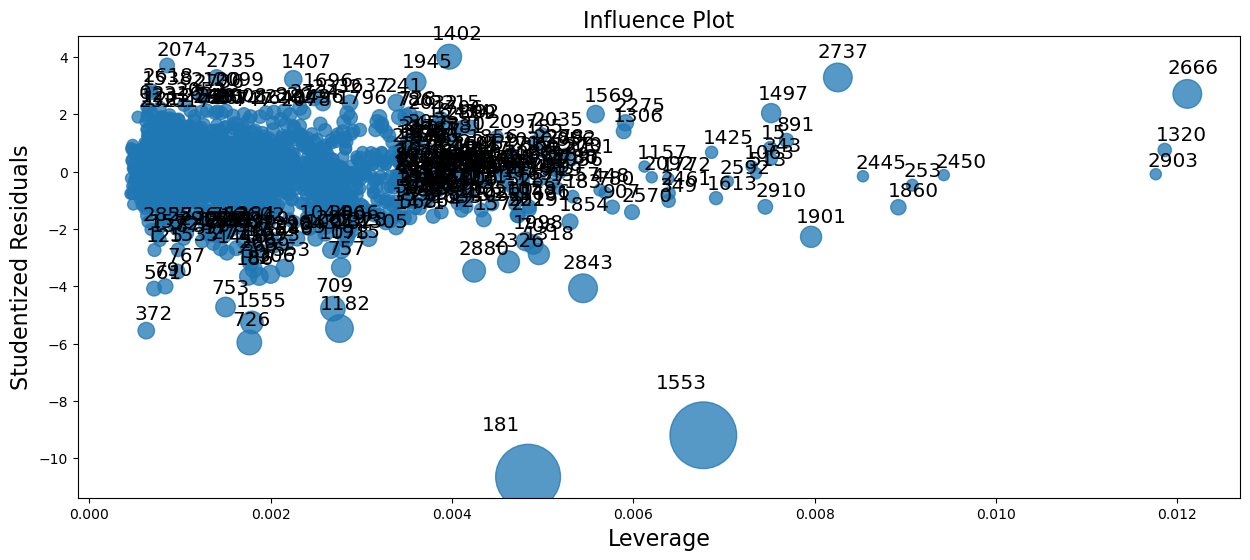

In [54]:
from statsmodels.graphics.regressionplots import influence_plot
fig, ax = plt.subplots(figsize=(15,6))
fig = influence_plot(model, ax=ax)

In [55]:
# Functions for checking influential points
def studResOutlier(model, sr_limit):
    influence = model.get_influence()

    # Studentized residuals
    stud_resid = influence.resid_studentized_external
    high_resid = np.abs(stud_resid) > sr_limit

    return high_resid

def levOutlier(model):
    influence = model.get_influence()

    # Leverage
    leverage = influence.hat_matrix_diag
    n = model.nobs
    p = len(model.model.exog_names) # number of predictors + target
    leverage_threshold = 3 * p / n
    print('Leverage Threshold:', leverage_threshold)
    high_leverage = leverage > leverage_threshold

    return high_leverage

In [56]:
# Check for outliers that have studentized residuals greater than abs(3) and are above leverage threshold
influential_points = studResOutlier(model, 3) & levOutlier(model)
outlier_indices=X_train_scaled.index[influential_points]
outlier_indices

Leverage Threshold: 0.005128205128205128


Index([1553, 2843, 2737], dtype='int64')

In [57]:
df.loc[[1553, 2843, 2737]]

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotFuncLivArea,NeighborhoodEncTrain,NeighborhoodEncTest,BsmtQualNum,ExterQualNum,KitchenQualNum,LogSalePrice
1553,1554,910251050,20,A (agr),80.0,14584,Pave,Reg,Low,AllPub,Inside,Mod,IDOTRR,Norm,Norm,1Fam,1Story,1,5,1952,1952,Gable,CompShg,AsbShng,VinylSd,NaN,0.0,Fa,Po,Slab,None,None,None,None,0.0,None,0.0,0.0,0.0,Wall,Po,N,FuseA,733,0,0,733,0.0,0.0,1,0,2,1,Fa,4,Sal,0,Attchd,1952.0,Unf,2.0,487.0,Fa,Po,N,0,0,0,0,0,0,0,2,2008,WD,Abnorml,13100,733.0,104327.667388,103928.545980,0,1,0,9.480368
2843,2844,909101330,30,RL,60.0,8088,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,2,3,1922,1955,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,498.0,498.0,GasA,TA,N,FuseF,498,0,0,498,0.0,0.0,1,0,1,1,TA,3,Typ,0,Detchd,1922.0,Unf,1.0,216.0,Fa,Fa,N,0,0,100,0,0,0,0,2,2006,ConLD,Normal,35000,498.0,129633.546858,130228.772354,2,2,1,10.463103
2737,2738,905427030,75,RL,60.0,19800,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,2.5Unf,6,8,1935,1990,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Rec,425.0,Unf,0.0,1411.0,1836.0,GasA,Gd,Y,SBrkr,1836,1836,0,3672,0.0,0.0,3,1,5,1,Gd,7,Typ,2,Detchd,1993.0,Unf,2.0,836.0,TA,TA,Y,684,80,32,0,0,0,0,12,2006,WD,Normal,415000,4097.0,128699.830763,130228.772354,2,2,2,12.936034


In [58]:
# Drop outliers
X_train_scaled = X_train_scaled.drop([1553, 2843, 2737])
y_train = y_train.drop([1553, 2843, 2737])

# Refit the model
model = sm.OLS(y_train, X_train_scaled).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     3893.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        20:58:38   Log-Likelihood:                 928.66
No. Observations:                2337   AIC:                            -1849.
Df Residuals:                    2333   BIC:                            -1826.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.0187      0.003   35

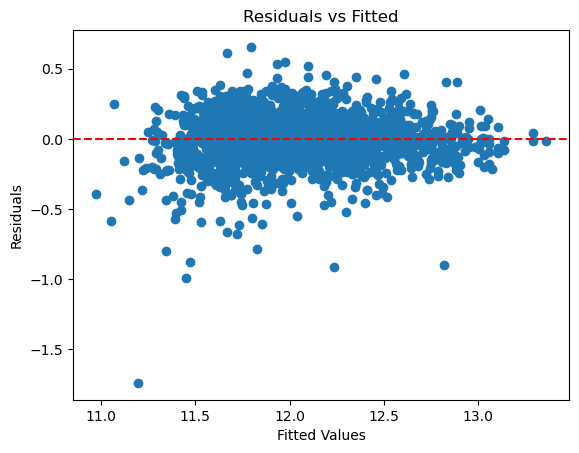

In [59]:
plt.scatter(model.fittedvalues , model.resid)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

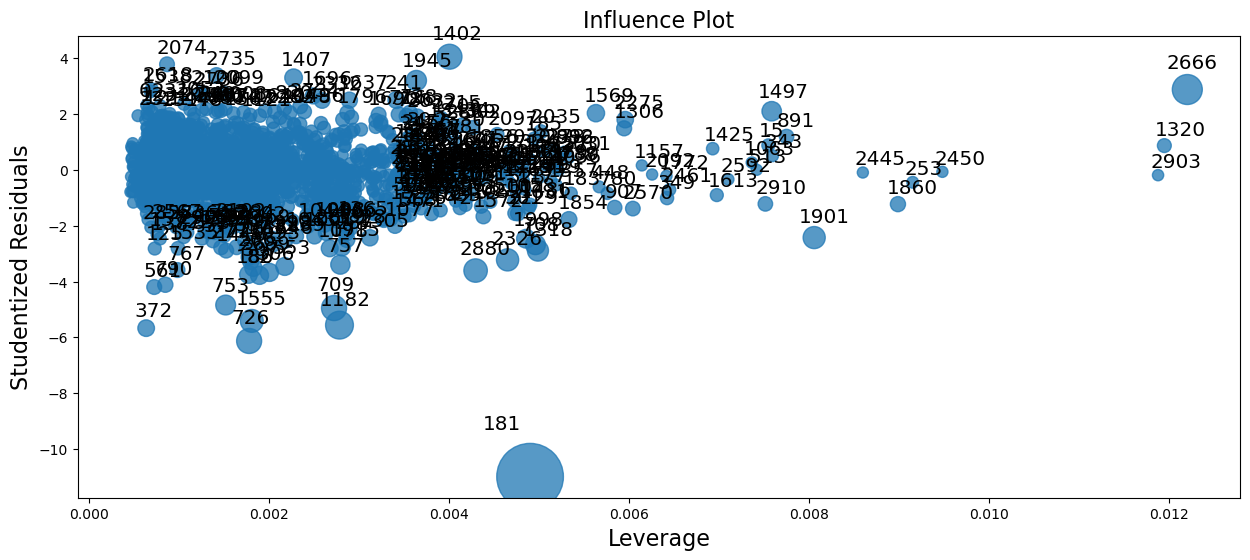

In [60]:
fig, ax = plt.subplots(figsize=(15,6))
fig = influence_plot(model, ax=ax)

In [61]:
# Check for outliers that have studentized residuals greater than abs(3) and are above leverage threshold - no more for now
influential_points = studResOutlier(model, 3) & levOutlier(model)
outlier_indices=X_train_scaled.index[influential_points]
outlier_indices

Leverage Threshold: 0.005134788189987163


Index([], dtype='int64')

In [62]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
y_pred = np.exp(y_pred) # Reverse the log transformation on actual prediction
y_test = np.exp(y_test) # Reverse the log transformation on test prediction

In [63]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_percentage_error

# Calculate R-squared, RMSE, and MAPE
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape_decimal = mean_absolute_percentage_error(y_test, y_pred)

print(f'R2: {r2}')
print(f'RMSE: {rmse}')
print(f'Mean Absolute Percentage Error: {mape_decimal * 100:.2f}%')

# Obtain predictor coefficients and store in dictionary
coefs = {
    'const': model.params['const'],
    'OverallQual': model.params['OverallQual'],
    'TotFuncLivArea': model.params['TotFuncLivArea'],
    'Neighborhood_te': model.params['Neighborhood_te']
}

# Convert dictionary to Series for easy calculation
beta = pd.Series(coefs)

# Calculate the percentage increase for a 1-unit increase in X
percent_change = (np.exp(beta) - 1) * 100

# Calculate percentage increase in SalePrice per 1-unit increase in feature
print('\nPercentage increase in SalePrice per 1-unit increase in feature:')
print(percent_change.drop('const').round(2).astype(str) + '%')

R2: 0.8885823034241415
RMSE: 28145.336531957455
Mean Absolute Percentage Error: 11.22%

Percentage increase in SalePrice per 1-unit increase in feature:
OverallQual         17.7%
TotFuncLivArea     17.03%
Neighborhood_te    11.01%
dtype: object


**Analysis:** The training model shows strong explanatory power (Adj. R-squared ≈ 0.833) and is statistically significant. All predictors are highly significant, and the low condition number indicates minimal multicollinearity, suggesting stable coefficient estimates.
The Durbin-Watson statistic (~1.96) indicates close to no autocorrelation. However, residual diagnostics (Omnibus and Jarque-Bera tests) clearly indicate non-normality, with heavy tails and slight negative skew.

Predictive performance is consistent (R-squared ≈ 0.889), suggesting no overfitting and good generalization. RMSE ($28.1K) and MAPE (11.22%) indicate reasonably good predictive accuracy for housing prices.

The log-linear model implies multiplicative effects: a one-unit increase in OverallQual, TotFuncLivArea, and Neighborhood_te is associated with approximately 18%, 17%, and 11% increases in SalePrice, respectively.